# Funciones de Activación Adicionales y Avanzadas

En este cuaderno exploraremos **6 funciones de activación adicionales** utilizadas en arquitecturas específicas como redes profundas autorreguladas, modelos probabilísticos y sistemas livianos para dispositivos móviles.

## 1. ELU (Exponential Linear Unit)

* **Cómo funciona:** Si la señal es positiva, pasa completa ($x$). Si es negativa, utiliza una curva exponencial que se amortigua suavemente hacia un límite $-\alpha$.
* **Fórmula:** $f(x) = x$ si $x > 0$, de lo contrario $\alpha(e^x - 1)$
* **Uso:** Redes profundas donde se busca acelerar la convergencia y suavizar las activaciones negativas.

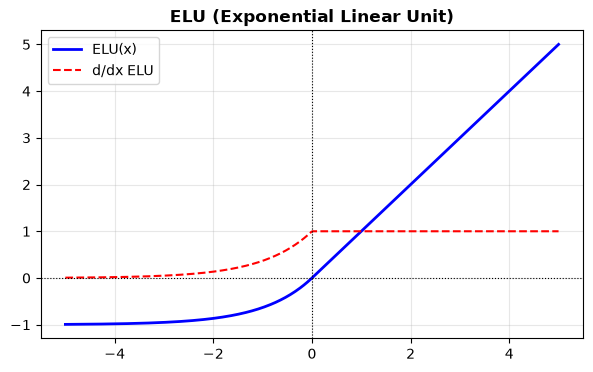

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def d_elu(x, alpha=1.0):
    return np.where(x > 0, 1.0, elu(x, alpha) + alpha)

x = np.linspace(-5, 5, 400)
plt.figure(figsize=(7, 4))
plt.plot(x, elu(x), label='ELU(x)', color='blue', linewidth=2)
plt.plot(x, d_elu(x), label='d/dx ELU', color='red', linestyle='--', linewidth=1.5)
plt.title('ELU (Exponential Linear Unit)', fontweight='bold')
plt.axhline(0, color='black', lw=0.8, ls=':')
plt.axvline(0, color='black', lw=0.8, ls=':')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 2. SELU (Scaled Exponential Linear Unit)

* **Cómo funciona:** Aplica una versión escalada de ELU con constantes fijas ($\lambda \approx 1.0507$, $\alpha \approx 1.6732$) que inducen propiedades de autorregulación en la red.
* **Fórmula:** $f(x) = \lambda \cdot \text{ELU}(x, \alpha)$
* **Uso:** Redes neuronales densas muy profundas (SNNs) sin necesidad de Batch Normalization.

In [ ]:
def selu(x, scale=1.0507009873554804934193349852946, alpha=1.6732632423543772848170429916717):
    return scale * np.where(x > 0, x, alpha * (np.exp(x) - 1))

plt.figure(figsize=(7, 4))
plt.plot(x, selu(x), label='SELU(x)', color='blue', linewidth=2)
plt.title('SELU (Scaled ELU)', fontweight='bold')
plt.axhline(0, color='black', lw=0.8, ls=':')
plt.axvline(0, color='black', lw=0.8, ls=':')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 3. PReLU (Parametric ReLU)

* **Cómo funciona:** A diferencia de Leaky ReLU, la pendiente en la zona negativa ($\alpha$) no es fija, sino un parámetro adaptable que la red aprende durante el entrenamiento.
* **Fórmula:** $f(x) = \max(\alpha x, x)$
* **Uso:** Arquitecturas de visión por computadora donde se requiere flexibilidad en zonas negativas.

In [ ]:
def prelu(x, alpha=0.25): # alpha suele ser un parámetro aprendible
    return np.where(x > 0, x, alpha * x)

plt.figure(figsize=(7, 4))
plt.plot(x, prelu(x, alpha=0.25), label='PReLU (alpha=0.25)', color='blue', linewidth=2)
plt.title('PReLU (Parametric ReLU)', fontweight='bold')
plt.axhline(0, color='black', lw=0.8, ls=':')
plt.axvline(0, color='black', lw=0.8, ls=':')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4. Softplus

* **Cómo funciona:** Produce una versión suave y diferenciable de ReLU sin codos ni esquinas marcadas en cero.
* **Fórmula:** $f(x) = \ln(1 + e^x)$
* **Uso:** Autoencoders Variacionales (VAEs) y estimación de parámetros positivos.

In [ ]:
def softplus(x):
    return np.log(1 + np.exp(x))

def d_softplus(x):
    return 1 / (1 + np.exp(-x)) # La derivada de Softplus es la función Sigmoide

plt.figure(figsize=(7, 4))
plt.plot(x, softplus(x), label='Softplus(x)', color='blue', linewidth=2)
plt.plot(x, d_softplus(x), label='d/dx Softplus (Sigmoide)', color='red', linestyle='--', linewidth=1.5)
plt.title('Softplus', fontweight='bold')
plt.axhline(0, color='black', lw=0.8, ls=':')
plt.axvline(0, color='black', lw=0.8, ls=':')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 5. Mish

* **Cómo funciona:** Combina $x$, $\tanh$ y $\text{Softplus}$ para crear un suave valle negativo que mejora la fluidez de los gradientes.
* **Fórmula:** $f(x) = x \cdot \tanh(\ln(1 + e^x))$
* **Uso:** Redes convolucionales de alta precisión como YOLOv4.

In [ ]:
def mish(x):
    return x * np.tanh(softplus(x))

plt.figure(figsize=(7, 4))
plt.plot(x, mish(x), label='Mish(x)', color='blue', linewidth=2)
plt.title('Mish', fontweight='bold')
plt.axhline(0, color='black', lw=0.8, ls=':')
plt.axvline(0, color='black', lw=0.8, ls=':')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. ReLU6

* **Cómo funciona:** Funciona como ReLU pero limita la salida máxima a $6$ para evitar problemas numéricos en operaciones de baja precisión.
* **Fórmula:** $f(x) = \min(\max(0, x), 6)$
* **Uso:** Modelos optimizados para móviles y hardware embebido (MobileNet).

In [ ]:
def relu6(x):
    return np.clip(np.maximum(0, x), 0, 6)

plt.figure(figsize=(7, 4))
plt.plot(x, relu6(x), label='ReLU6(x)', color='blue', linewidth=2)
plt.title('ReLU6', fontweight='bold')
plt.axhline(0, color='black', lw=0.8, ls=':')
plt.axvline(0, color='black', lw=0.8, ls=':')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()